In [1]:
%pip install tensorflow pandas numpy -q

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [4]:
translation_pairs = [
    ('привет', 'hola'),
    ('здравствуй', 'hola'),
    ('доброе утро', 'buenos días'),
    ('добрый день', 'buenas tardes'),
    ('добрый вечер', 'buenas noches'),
    ('спокойной ночи', 'buenas noches'),
    ('спасибо', 'gracias'),
    ('большое спасибо', 'muchas gracias'),
    ('пожалуйста', 'por favor'),
    ('извини', 'lo siento'),
    ('как дела', 'cómo estás'),
    ('я хорошо', 'estoy bien'),
    ('я плохо', 'estoy mal'),
    ('я устал', 'estoy cansado'),
    ('я голоден', 'tengo hambre'),
    ('я хочу воды', 'quiero agua'),
    ('я хочу есть', 'quiero comer'),
    ('где туалет', 'dónde está el baño'),
    ('сколько стоит', 'cuánto cuesta'),
    ('это дорого', 'esto es caro'),
    ('это дешево', 'esto es barato'),
    ('я студент', 'soy estudiante'),
    ('я преподаватель', 'soy profesor'),
    ('я из перу', 'soy de perú'),
    ('ты говоришь по испански', 'hablas español'),
    ('я говорю по русски', 'hablo ruso'),
    ('я не понимаю', 'no entiendo'),
    ('повтори пожалуйста', 'repite por favor'),
    ('я тебя люблю', 'te quiero'),
    ('я скучаю по тебе', 'te extraño'),
    ('до свидания', 'adiós'),
    ('увидимся завтра', 'nos vemos mañana'),
    ('сегодня холодно', 'hoy hace frío'),
    ('сегодня жарко', 'hoy hace calor'),
    ('мне нравится музыка', 'me gusta la música'),
    ('мне нравится кофе', 'me gusta el café'),
    ('я люблю читать', 'me gusta leer'),
    ('я люблю путешествовать', 'me gusta viajar'),
    ('это мой друг', 'este es mi amigo'),
    ('это моя подруга', 'esta es mi amiga'),
    ('у меня есть вопрос', 'tengo una pregunta'),
    ('помоги мне', 'ayúdame'),
    ('открой дверь', 'abre la puerta'),
    ('закрой дверь', 'cierra la puerta'),
    ('я дома', 'estoy en casa'),
    ('я в университете', 'estoy en la universidad'),
    ('я работаю', 'estoy trabajando'),
    ('я учусь', 'estoy estudiando'),
    ('мне нужно идти', 'tengo que irme'),
    ('до завтра', 'hasta mañana'),
]

df = pd.DataFrame(translation_pairs, columns=['ruso', 'espanol'])
df.head(10)

,ruso,espanol
0,привет,hola
1,здравствуй,hola
2,доброе утро,buenos días
3,добрый день,buenas tardes
4,добрый вечер,buenas noches
5,спокойной ночи,buenas noches
6,спасибо,gracias
7,большое спасибо,muchas gracias
8,пожалуйста,por favor
9,извини,lo siento


In [5]:
df['target_input'] = '<start> ' + df['espanol']
df['target_output'] = df['espanol'] + ' <end>'

df.head()

,ruso,espanol,target_input,target_output
0,привет,hola,<start> hola,hola <end>
1,здравствуй,hola,<start> hola,hola <end>
2,доброе утро,buenos días,<start> buenos días,buenos días <end>
3,добрый день,buenas tardes,<start> buenas tardes,buenas tardes <end>
4,добрый вечер,buenas noches,<start> buenas noches,buenas noches <end>


In [6]:
input_tokenizer = Tokenizer(filters='')
input_tokenizer.fit_on_texts(df['ruso'])

target_tokenizer = Tokenizer(filters='')
target_tokenizer.fit_on_texts(pd.concat([df['target_input'], df['target_output']]))

input_sequences = input_tokenizer.texts_to_sequences(df['ruso'])
target_input_sequences = target_tokenizer.texts_to_sequences(df['target_input'])
target_output_sequences = target_tokenizer.texts_to_sequences(df['target_output'])

print('Ejemplo ruso tokenizado:', input_sequences[0])
print('Ejemplo español entrada tokenizado:', target_input_sequences[0])
print('Ejemplo español salida tokenizado:', target_output_sequences[0])

Ejemplo ruso tokenizado: [16]
Ejemplo español entrada tokenizado: [1, 12]
Ejemplo español salida tokenizado: [12, 2]


In [7]:
max_encoder_seq_length = max(len(seq) for seq in input_sequences)
max_decoder_seq_length = max(len(seq) for seq in target_input_sequences)

encoder_input_data = pad_sequences(
    input_sequences,
    maxlen=max_encoder_seq_length,
    padding='post'
)

decoder_input_data = pad_sequences(
    target_input_sequences,
    maxlen=max_decoder_seq_length,
    padding='post'
)

decoder_target_data = pad_sequences(
    target_output_sequences,
    maxlen=max_decoder_seq_length,
    padding='post'
)

num_encoder_tokens = len(input_tokenizer.word_index) + 1
num_decoder_tokens = len(target_tokenizer.word_index) + 1

print('Longitud máxima encoder:', max_encoder_seq_length)
print('Longitud máxima decoder:', max_decoder_seq_length)
print('Vocabulario ruso:', num_encoder_tokens)
print('Vocabulario español:', num_decoder_tokens)

Longitud máxima encoder: 4
Longitud máxima decoder: 5
Vocabulario ruso: 79
Vocabulario español: 84


In [8]:
decoder_target_data = np.expand_dims(decoder_target_data, -1)
decoder_target_data.shape

(50, 5, 1)

In [9]:
embedding_dim = 64
latent_dim = 128

# Encoder
encoder_inputs = Input(shape=(None,), name='encoder_inputs')
encoder_embedding = Embedding(
    input_dim=num_encoder_tokens,
    output_dim=embedding_dim,
    mask_zero=True,
    name='encoder_embedding'
)(encoder_inputs)

encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
_, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None,), name='decoder_inputs')
decoder_embedding_layer = Embedding(
    input_dim=num_decoder_tokens,
    output_dim=embedding_dim,
    mask_zero=True,
    name='decoder_embedding'
)
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name='decoder_lstm'
)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

decoder_dense = Dense(num_decoder_tokens, activation='softmax', name='decoder_dense')
decoder_outputs = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, None, 64)  │      5,056 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 64)  │      5,376 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     98,816 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │     98,816 │ decoder_embeddin… │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128), (None,      │            │ encoder_lstm[0][… │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 84)  │     10,836 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 218,900 (855.08 KB)

 Trainable params: 218,900 (855.08 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=8,
    epochs=300,
    validation_split=0.2,
    verbose=0
)

print('Entrenamiento finalizado.')

Entrenamiento finalizado.


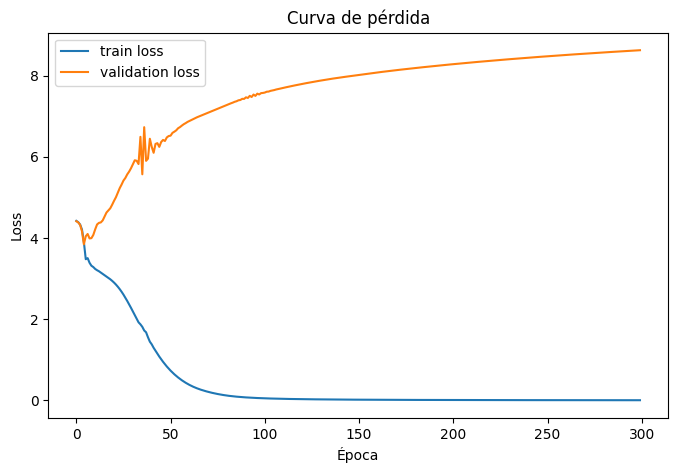

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida')
plt.legend()
plt.show()

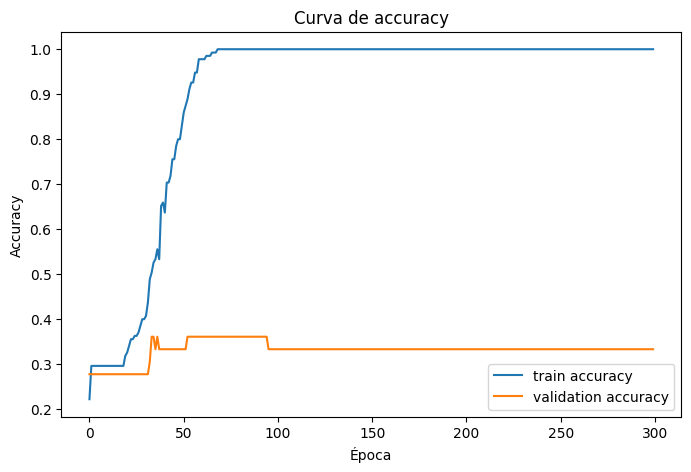

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Curva de accuracy')
plt.legend()
plt.show()

In [13]:
encoder_model = Model(encoder_inputs, encoder_states)

decoder_state_input_h = Input(shape=(latent_dim,), name='decoder_state_input_h')
decoder_state_input_c = Input(shape=(latent_dim,), name='decoder_state_input_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single = Input(shape=(1,), name='decoder_input_single')
decoder_embedding_single = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs_single, state_h_single, state_c_single = decoder_lstm(
    decoder_embedding_single,
    initial_state=decoder_states_inputs
)
decoder_states_single = [state_h_single, state_c_single]
decoder_outputs_single = decoder_dense(decoder_outputs_single)

decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [decoder_outputs_single] + decoder_states_single
)

In [14]:
reverse_target_word_index = {
    index: word for word, index in target_tokenizer.word_index.items()
}

start_token = target_tokenizer.word_index['<start>']
end_token = target_tokenizer.word_index['<end>']


def translate(sentence):
    sequence = input_tokenizer.texts_to_sequences([sentence])
    sequence = pad_sequences(
        sequence,
        maxlen=max_encoder_seq_length,
        padding='post'
    )

    states_value = encoder_model.predict(sequence, verbose=0)

    target_sequence = np.array([[start_token]])
    translated_words = []

    for _ in range(max_decoder_seq_length):
        output_tokens, h, c = decoder_model.predict(
            [target_sequence] + states_value,
            verbose=0
        )

        sampled_token_index = np.argmax(output_tokens[0, -1, :])

        if sampled_token_index == end_token:
            break

        sampled_word = reverse_target_word_index.get(sampled_token_index, '')

        if sampled_word:
            translated_words.append(sampled_word)

        target_sequence = np.array([[sampled_token_index]])
        states_value = [h, c]

    return ' '.join(translated_words)

In [15]:
test_sentences = [
    'привет',
    'спасибо',
    'я тебя люблю',
    'доброе утро',
    'я студент',
    'я не понимаю',
]

for sentence in test_sentences:
    print(f'{sentence}  ->  {translate(sentence)}')

привет  ->  hola
спасибо  ->  gracias
я тебя люблю  ->  te quiero
доброе утро  ->  buenos días
я студент  ->  soy estudiante
я не понимаю  ->  no entiendo


In [16]:
new_sentences = [
    'я люблю кофе',
    'ты студент',
    'мне нравится русский',
]

for sentence in new_sentences:
    print(f'{sentence}  ->  {translate(sentence)}')

я люблю кофе  ->  me gusta viajar
ты студент  ->  soy estudiante
мне нравится русский  ->  me gusta el


In [17]:
model.save('russian_spanish_seq2seq_lstm.keras')
print('Modelo guardado como russian_spanish_seq2seq_lstm.keras')

Modelo guardado como russian_spanish_seq2seq_lstm.keras


# **CODIGO AÑADIDO**

In [18]:
frases_nuevas = [
    ("привет", "hola"),
    ("как дела", "como estas"),
    ("доброе утро", "buenos dias"),
    ("спокойной ночи", "buenas noches"),
    ("я люблю тебя", "te amo"),
    ("спасибо", "gracias"),
    ("пожалуйста", "por favor"),
    ("извините", "perdon"),
    ("я не понимаю", "no entiendo"),
    ("где туалет", "donde esta el bano"),
    ("сколько это стоит", "cuanto cuesta"),
    ("очень хорошо", "muy bien"),
    ("до свидания", "adios"),
    ("меня зовут", "me llamo"),
    ("рад познакомиться", "encantado de conocerte"),
    ("я хочу есть", "tengo hambre"),
    ("я устал", "estoy cansado"),
    ("хорошая погода", "buen clima"),
    ("что ты делаешь", "que haces"),
    ("пошли", "vamos")
]

In [20]:
historial_reentrenamiento = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=64,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.3333 - val_loss: 8.6276
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.3333 - val_loss: 8.6281
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.3333 - val_loss: 8.6286
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.3333 - val_loss: 8.6291
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.3333 - val_loss: 8.6296
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.3333 - val_loss: 8.6301
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.3333 - val_loss: 8.6306
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.3333 - val_loss: 8.

In [22]:

new_sentences = [
    'я люблю кофе',         # (me gusta el cafe)
    'ты студент',           # (tu eres estudiante)
    'мне нравится русский', # (me gusta el ruso)
    'я хочу есть',          # (tengo hambre - vista en el entrenamiento nuevo)
    'до свидания'           # (adios - vista en el entrenamiento nuevo)
]

print("--- RESULTADOS DE LAS PRUEBAS ---")
for sentence in new_sentences:
    print(f'{sentence}  ->  {translate(sentence)}')

--- RESULTADOS DE LAS PRUEBAS ---
я люблю кофе  ->  me gusta viajar
ты студент  ->  soy estudiante
мне нравится русский  ->  me gusta el
я хочу есть  ->  quiero comer
до свидания  ->  adiós
